# Extreme Value Type I (Gumbel) Distribution

The **Gumbel (Extreme Value Type I) distribution** models the maximum (or minimum) of a large collection of independent variables. It is the natural distribution for the largest value in a sample — flood levels, wind speeds, maximum temperatures, material breaking strengths.

| Property | Value |
|---|---|
| **Parameters** | $\mu$ (location), $\beta$ (scale, $\beta > 0$) |
| **Support** | $(-\infty, +\infty)$ |
| **PDF (max)** | $\displaystyle f(x) = \frac{1}{\beta} \exp\!\left(-z - e^{-z}\right)$, $z = (x-\mu)/\beta$ |
| **CDF (max)** | $F(x) = \exp\!\left(-\exp\!\left(-\dfrac{x-\mu}{\beta}\right)\right)$ |
| **Mean** | $\mu + 0.5772\,\beta$ (Euler–Mascheroni constant) |
| **Median** | $\mu - \beta\ln(\ln 2)$ |
| **Mode** | $\mu$ |
| **Std Dev** | $\beta\pi/\sqrt{6}$ |
| **Skewness** | $1.14$ (always right-skewed for max case) |
| **Kurtosis** | $5.4$ (heavy tails) |
| **Estimation** | MOM: $\hat{\mu} = \bar{x} - 0.5772\hat{\beta}$, $\hat{\beta} = s\sqrt{6}/\pi$ |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Visualising the Gumbel Distribution

### Panel 1 — PDF: Location and Scale Parameters
Each curve shows the **Gumbel PDF** $f(x) = \frac{1}{\beta}\exp(-z - e^{-z})$ where $z=(x-\mu)/\beta$ for different $\mu$ and $\beta$. All curves are right-skewed; $\mu$ shifts the location and $\beta$ controls the spread.

### Panel 2 — Max vs Min Extreme Value
The **Gumbel-R** (for block maxima, right-skewed) and **Gumbel-L** (for block minima, left-skewed) are mirror images. Both arise as the limiting distribution of block extremes from distributions with exponential-like tails.

### Panel 3 — Block Maxima Convergence to Gumbel
Block maxima of Normal samples (2000 blocks of $n=100$) are fitted with a Gumbel distribution, demonstrating the **Extreme Value Theorem**: block maxima from any distribution with exponential-like tails converge to the Gumbel in the limit.


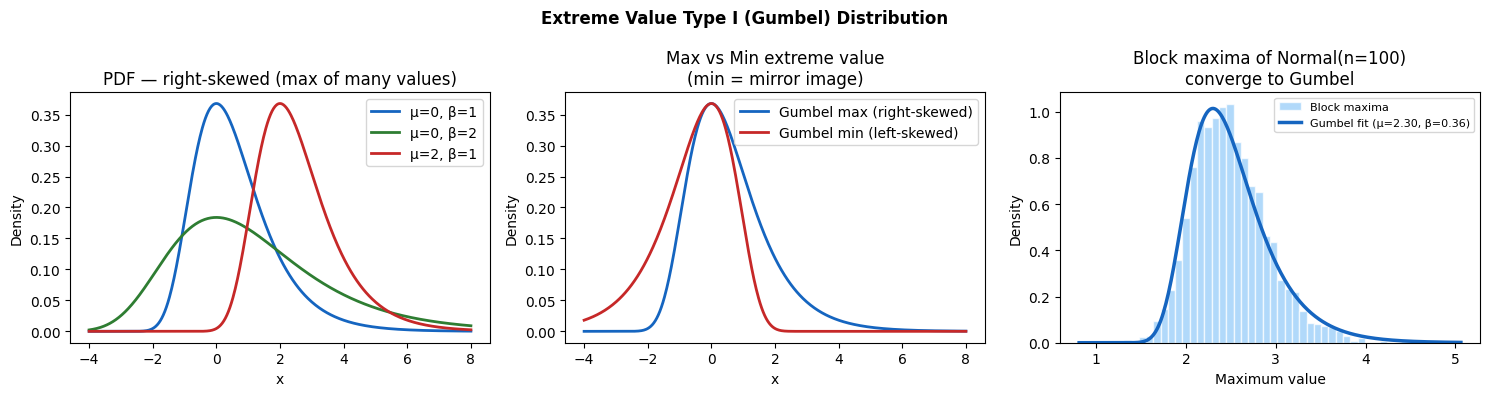

Block maxima: mean=2.496, std=0.416
Gumbel fit: μ=2.300, β=0.363


In [2]:
# scipy: stats.gumbel_r = max (right-skewed), stats.gumbel_l = min (left-skewed)
x = np.linspace(-4, 8, 500)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Extreme Value Type I (Gumbel) Distribution', fontsize=12, fontweight='bold')

# PDF
for mu, beta, color, label in [(0, 1,   '#1565C0', 'μ=0, β=1'),
                                (0, 2,   '#2E7D32', 'μ=0, β=2'),
                                (2, 1,   '#C62828', 'μ=2, β=1')]:
    axes[0].plot(x, stats.gumbel_r(loc=mu, scale=beta).pdf(x), color=color, linewidth=2, label=label)
axes[0].set_title('PDF — right-skewed (max of many values)')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].legend()

# Max and min variants
axes[1].plot(x, stats.gumbel_r(0,1).pdf(x), color='#1565C0', linewidth=2, label='Gumbel max (right-skewed)')
axes[1].plot(x, stats.gumbel_l(0,1).pdf(x), color='#C62828', linewidth=2, label='Gumbel min (left-skewed)')
axes[1].set_title('Max vs Min extreme value\n(min = mirror image)')
axes[1].set_xlabel('x'); axes[1].set_ylabel('Density')
axes[1].legend()

# Extreme value convergence: max of n normals → Gumbel
np.random.seed(42)
n_obs = 100    # sample size per block
n_blocks = 2000
block_maxima = [np.max(np.random.normal(0, 1, n_obs)) for _ in range(n_blocks)]
block_maxima = np.array(block_maxima)

# Fit Gumbel
loc_fit, scale_fit = stats.gumbel_r.fit(block_maxima)[:2]

axes[2].hist(block_maxima, bins=40, density=True, color='#90CAF9', edgecolor='white',
             alpha=0.7, label='Block maxima')
x_fit = np.linspace(block_maxima.min()-0.5, block_maxima.max()+0.5, 300)
axes[2].plot(x_fit, stats.gumbel_r(loc=loc_fit, scale=scale_fit).pdf(x_fit),
             color='#1565C0', linewidth=2.5, label=f'Gumbel fit (μ={loc_fit:.2f}, β={scale_fit:.2f})')
axes[2].set_title(f'Block maxima of Normal(n={n_obs})\nconverge to Gumbel')
axes[2].set_xlabel('Maximum value'); axes[2].set_ylabel('Density')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Block maxima: mean={block_maxima.mean():.3f}, std={block_maxima.std():.3f}")
print(f"Gumbel fit: μ={loc_fit:.3f}, β={scale_fit:.3f}")

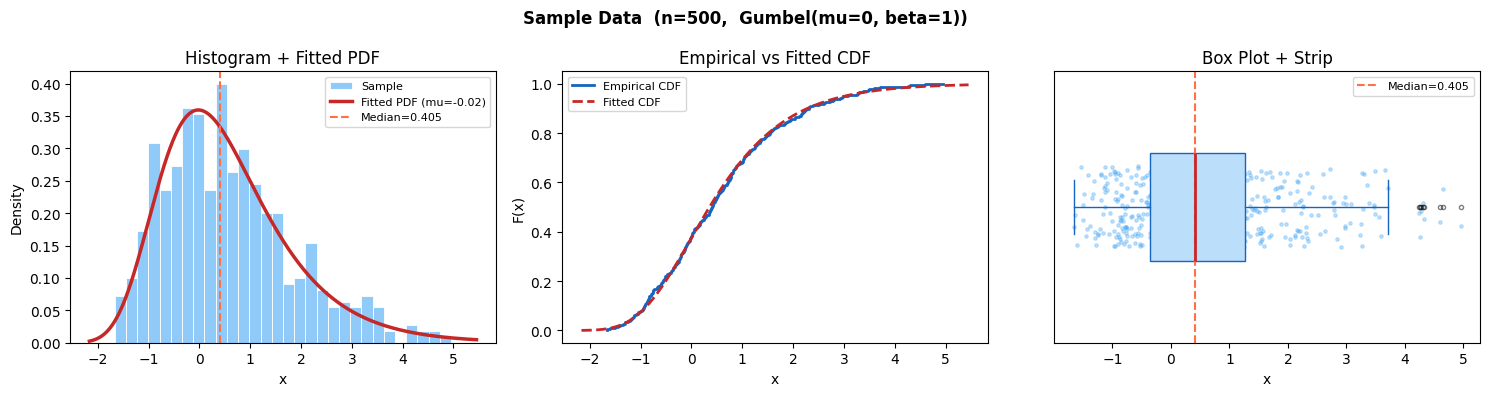

n=500  mean=0.5709  median=0.4047  std=1.2809  skew=0.7730  kurtosis=0.3464


In [3]:
# Sample data plots — Gumbel(mu=0, beta=1)
np.random.seed(42)
sample_d = stats.gumbel_r.rvs(loc=0, scale=1, size=500)
loc_hat, scale_hat = stats.gumbel_r.fit(sample_d)
x_fit = np.linspace(sample_d.min() - 0.5, sample_d.max() + 0.5, 400)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Sample Data  (n=500,  Gumbel(mu=0, beta=1))', fontsize=12, fontweight='bold')

# Histogram + fitted PDF
axes[0].hist(sample_d, bins=30, density=True,
             color='#90CAF9', edgecolor='white', linewidth=0.6, label='Sample')
axes[0].plot(x_fit, stats.gumbel_r(loc_hat, scale_hat).pdf(x_fit),
             color='#C62828', linewidth=2.5, label=f'Fitted PDF (mu={loc_hat:.2f})')
axes[0].axvline(np.median(sample_d), color='#FF7043', linewidth=1.5, linestyle='--',
                label=f'Median={np.median(sample_d):.3f}')
axes[0].set_title('Histogram + Fitted PDF')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

# Empirical vs fitted CDF
sorted_s = np.sort(sample_d)
ecdf = np.arange(1, len(sorted_s) + 1) / len(sorted_s)
axes[1].step(sorted_s, ecdf, color='#1565C0', linewidth=2, label='Empirical CDF')
axes[1].plot(x_fit, stats.gumbel_r(loc_hat, scale_hat).cdf(x_fit),
             color='#C62828', linewidth=2, linestyle='--', label='Fitted CDF')
axes[1].set_title('Empirical vs Fitted CDF')
axes[1].set_xlabel('x'); axes[1].set_ylabel('F(x)')
axes[1].legend(fontsize=8)

# Box plot + strip
axes[2].boxplot(sample_d, vert=False, patch_artist=True, widths=0.4,
                boxprops=dict(facecolor='#BBDEFB', color='#1565C0'),
                medianprops=dict(color='#C62828', linewidth=2),
                whiskerprops=dict(color='#1565C0'),
                capprops=dict(color='#1565C0'),
                flierprops=dict(marker='o', color='#FF7043', markersize=3, alpha=0.5))
axes[2].scatter(sample_d, np.random.uniform(0.85, 1.15, len(sample_d)),
                color='#42A5F5', s=6, alpha=0.3)
axes[2].axvline(np.median(sample_d), color='#FF7043', linewidth=1.5, linestyle='--',
                label=f'Median={np.median(sample_d):.3f}')
axes[2].set_title('Box Plot + Strip')
axes[2].set_xlabel('x'); axes[2].set_yticks([])
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()
print(f"n={len(sample_d)}  mean={sample_d.mean():.4f}  median={np.median(sample_d):.4f}  std={sample_d.std(ddof=1):.4f}  skew={stats.skew(sample_d):.4f}  kurtosis={stats.kurtosis(sample_d):.4f}")


## Key Takeaways

| | |
|---|---|
| **EVT** | Block maxima from any distribution with exponential-like tails converge to Gumbel |
| **Right-skewed** | Skewness=1.14 — heavy right tail (extreme max events) |
| **Mode=μ** | The mode is the location parameter — peak is at $\mu$ |
| **Mean** | $\mu + \gamma\beta$ where $\gamma \approx 0.5772$ (Euler–Mascheroni constant) |
| **Max vs Min** | Gumbel_r for maxima, Gumbel_l for minima (mirror image) |
| **Return period** | $P(X > x) = 1 - \exp\!\left(-\exp\!\left(-\dfrac{x-\mu}{\beta}\right)\right)$ — T-year flood level |
| **Use cases** | Flood levels, wind speeds, earthquake magnitudes, stock losses |
